In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime as dt
import random
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
import numpy as np, pandas as pd
from tqdm import tqdm


In [2]:
# Custom functions for alpha calculations
import importlib.util
import sys
from WorldQuant_alpha101_code.alphas import *
from WorldQuant_alpha101_code.test_alphas import *

# # Load the module with importlib
# spec = importlib.util.spec_from_file_location(
#     "alpha_module", 
#     "/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/Raymon_code/WorldQuant_alpha101_code/alphas.py"
# )
# alpha_module = importlib.util.module_from_spec(spec)
# sys.modules["alpha_module"] = alpha_module
# spec.loader.exec_module(alpha_module)

# Now you can use it
# Alphas = Alphas

#### Part 0: Obtaining stock data

In [3]:
tickers = ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV']
industries = {'XLB': 'Buildings',
             'XLE': 'Energy',
             'XLF': 'Financials',
             'XLI': 'Industrials',
             'XLK': 'Technology',
             'XLP': 'Consumer Staples',
             'XLU': 'Utilities',
             'XLV': 'Healthcare'
             }
start_date = dt.datetime(2000,1,1)
end_date = dt.datetime(2025,10,1)

stock_data = yf.download(tickers, start_date, end_date,auto_adjust=False)
tickers = stock_data['Close'].columns.tolist()

[*********************100%***********************]  8 of 8 completed


In [4]:
stock_data = stock_data.drop(columns=['Close']).rename(columns={'Adj Close':'Close'})

In [5]:
# Calculate returns for each ticker separately
returns = stock_data['Close'].pct_change()

# Add as new top-level column
for ticker in stock_data['Close'].columns:
    stock_data[('Returns', ticker)] = returns[ticker]

In [6]:
nav_dict = {}
for ticker in tickers:
    df = pd.read_excel(f'ETF data/navhist-us-en-{ticker.lower()}.xlsx',
                                     skiprows=3)
    df = df[['Date','Shares Outstanding']]
    df = df[~(df['Shares Outstanding'].isnull()) & ~(df['Shares Outstanding']=='-')]
    df['Date'] = pd.to_datetime(df['Date'])
    df['Shares Outstanding'] = df['Shares Outstanding'].astype(float)
    df = df.set_index('Date')

    nav_dict[ticker] = df.sort_index(ascending=True).copy()

In [7]:
# nav_dict['XLP'][nav_dict['XLP'].columns[3]]
df = nav_dict['XLP']

df

,Shares Outstanding
Date,
2006-05-31,46954018.0
2006-06-01,46954018.0
2006-06-02,46954018.0
2006-06-05,46954018.0
2006-06-06,46954018.0
...,...
2025-09-29,203671809.0
2025-09-30,205421809.0
2025-10-01,204871809.0


In [8]:
for ticker, df in nav_dict.items():
    stock_data[('Shares Outstanding', ticker)] = df['Shares Outstanding']
    

In [9]:
stock_data['Close']

Ticker,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV
Date,,,,,,,,
2000-01-03,14.595763,13.513023,11.186884,18.187746,41.366722,12.305078,11.186382,20.612183
2000-01-04,14.455246,13.258662,10.697833,17.685266,39.268074,11.958583,10.848946,20.144451
2000-01-05,15.052424,13.608413,10.613778,17.606451,38.685104,12.169863,11.122710,19.963732
2000-01-06,15.438838,14.133033,11.079898,17.842913,37.402596,12.398046,11.103610,20.027510
2000-01-07,15.430052,14.284069,11.263291,18.522730,38.055515,13.184025,11.199115,20.272001
...,...,...,...,...,...,...,...,...
2025-09-24,88.980003,90.339996,53.610001,152.250000,278.489990,78.519997,86.250000,136.389999
2025-09-25,87.820000,91.150002,53.470001,151.220001,278.000000,77.769997,85.419998,134.130005
2025-09-26,88.839996,91.989998,53.860001,152.580002,278.839996,77.959999,86.809998,135.500000


In [10]:
for ticker in tickers:
    stock_data[('Market_Cap', ticker)] = stock_data[('Close', ticker)] * stock_data[('Shares Outstanding', ticker)]
stock_data = stock_data.dropna(subset=[('Market_Cap', ticker) for ticker in tickers], how='all')

In [11]:
stock_data

Price           Close                                                \
Ticker            XLB        XLE        XLF         XLI         XLK   
Date                                                                  
2006-05-31  20.957918  31.328527  18.004286   23.253641   15.806787   
2006-06-01  21.186081  31.413118  18.213646   23.493439   16.077583   
2006-06-02  21.388161  31.881214  18.318323   23.527700   16.023422   
2006-06-05  20.749319  30.877348  18.020815   23.020700   15.783579   
2006-06-06  20.573317  30.849144  17.976744   22.931627   15.783579   
...               ...        ...        ...         ...         ...   
2025-09-24  88.980003  90.339996  53.610001  152.250000  278.489990   
2025-09-25  87.820000  91.150002  53.470001  151.220001  278.000000   
2025-09-26  88.839996  91.989998  53.860001  152.580002  278.839996   
2025-09-29  89.180000  90.300003  54.130001  153.050003  280.329987   
2025-09-30  89.620003  89.339996  53.869999  154.229996  281.859985   

Price                                              High             ...  \
Ticker            XLP        XLU         XLV        XLB        XLE  ...   
Date                                                                ...   
2006-05-31  14.278773  16.171600   21.696350  32.400002  55.549999  ...   
2006-06-01  14.356513  16.334185   22.003864  32.560001  55.990002  ...   
2006-06-02  14.326616  16.532320   22.089664  32.869999  56.630001  ...   
2006-06-05  14.123316  16.334185   21.746412  32.770000  57.180000  ...   
2006-06-06  14.165172  16.364664   21.782171  31.750000  55.360001  ...   
...               ...        ...         ...        ...        ...  ...   
2025-09-24  78.519997  86.250000  136.389999  90.169998  91.180000  ...   
2025-09-25  77.769997  85.419998  134.130005  88.680000  91.239998  ...   
2025-09-26  77.959999  86.809998  135.500000  88.989998  92.910004  ...   
2025-09-29  78.110001  87.059998  135.899994  89.470001  91.480003  ...   
2025-09-30  78.370003  87.209999  139.169998  89.690002  89.699997  ...   

Price      Shares Outstanding                 Market_Cap                \
Ticker                    XLU          XLV           XLB           XLE   
Date                                                                     
2006-05-31         69633629.0   55953600.0  5.870635e+08  2.559778e+09   
2006-06-01         69983629.0   55503600.0  5.934547e+08  2.430043e+09   
2006-06-02         69283629.0   55503600.0  5.991153e+08  2.396115e+09   
2006-06-05         69283629.0   55503600.0  5.915950e+08  2.311403e+09   
2006-06-06         67333629.0   55503600.0  5.732042e+08  2.142707e+09   
...                       ...          ...           ...           ...   
2025-09-24        243324160.0  245565324.0  5.367605e+09  2.701385e+10   
2025-09-25        242924160.0  244965324.0  5.332758e+09  2.719681e+10   
2025-09-26        243074160.0  243515324.0  5.390254e+09  2.760842e+10   
2025-09-29        242924160.0  244115324.0  5.397506e+09  2.728182e+10   
2025-09-30        244024160.0  244315324.0  5.459984e+09  2.692477e+10   

Price                                                               \
Ticker               XLF           XLI           XLK           XLP   
Date                                                                 
2006-05-31  1.226331e+09  7.326537e+08  1.160274e+09  6.704458e+08   
2006-06-01  1.223288e+09  7.402090e+08  1.180152e+09  6.740960e+08   
2006-06-02  1.220243e+09  7.412885e+08  1.176176e+09  6.726922e+08   
2006-06-05  1.182405e+09  7.253144e+08  1.166462e+09  6.631464e+08   
2006-06-06  1.184906e+09  7.225080e+08  1.166462e+09  6.651117e+08   
...                  ...           ...           ...           ...   
2025-09-24  5.314603e+10  2.351136e+10  8.899312e+10  1.569001e+10   
2025-09-25  5.294842e+10  2.333718e+10  8.869754e+10  1.569957e+10   
2025-09-26  5.322151e+10  2.356232e+10  8.893766e+10  1.581978e+10   
2025-09-29  5.310670e+10  2.371908e+10  8.941290e+10  1.590881e+10   
2025-09

#### Part 1: Factor construction

Start with raw stock data. Compute 82 of 101 alphas

- Core Alpha101-style technical factors

In [12]:
Alphas = Alphas(stock_data)

In [13]:
# # Test all alphas
# test_results = test_all_alphas(stock_data, alpha_module, verbose=False)

# Dealing with NaNs in Alphas
## Source of NaNs
a. Rolling window
    - these occur when there is a rolling window that results in NaNs at the start of the alpha created

b. Systematic NaNs
    - these occur due to systematic computation of the formula that results in NaNs happening sporadically. 
    - Need to further investigate these

In [14]:
# alphas_with_systematic_nans =\
# [(alpha, test_results['results'][alpha]['systematic_nans_frac']) 
#     for alpha in test_results['results'] 
#         if test_results['results'][alpha]['systematic_nans_frac'] > 0]
# [x[0] for x in alphas_with_systematic_nans]

# Alphas.alpha071().head(3000).isnull().sum()
# Alphas.alpha015()

In [15]:
# List all alpha methods in the Alphas class
alpha_methods = \
[method for method in dir(Alphas) 
            if method.startswith('alpha') and method[5:].isdigit()]

In [16]:
# stock_data['Returns']
Alphas.alpha050().stack().head(10)
# len(factors_df.columns)
# factors_df.tail(20).isnull().sum().sort_values()
# factors_df['alpha021'].value_counts()
# factors_df.tail()
# factors_df.shape
# stock_data['Market_Cap'].tail()
# factors_df.sort_index()

Date        Ticker
2006-06-12  XLB      -0.509154
            XLE      -0.538367
            XLF      -0.671055
            XLI      -0.685044
            XLK      -0.793664
            XLP      -0.285538
            XLU      -0.832545
            XLV      -0.747377
2006-06-13  XLB      -0.509154
            XLE      -0.676404
dtype: float64

In [17]:
# factor application function
def build_factor_table(stock_data, alpha_methods, alphas_instance, industry_map, gap=1, horizon=21):
    """Build a long-format factor table.

    Compute specified alpha series, concatenate into a long DataFrame (date, ticker),
    attach market capitalization and industry, and compute forward returns
    using `gap` and `horizon`.

    Inputs:
        stock_data (pd.DataFrame): price/metrics panel with MultiIndex columns
            like ('Close', ticker) and ('Market_Cap', ticker).
        alpha_methods (iterable[str]): names of alpha methods to call on
            alphas_instance (e.g. ['alpha001', 'alpha050']).
        alphas_instance (object): instance or class exposing alpha methods that
            return DataFrame (dates x tickers).
        industry_map (dict): mapping {ticker: industry_name}.
        gap (int): days to skip before the forward-return window (default 1).
        horizon (int): forward-return window length in days (default 21).

    Returns:
        pd.DataFrame: index (date, ticker) with alpha columns, 'market_cap', 'industry', 'forward_return'.
    """
    CLIPPING_VALUE = 1e6
    #  ---------- Step 1: Get Alphas ----------
    factors = []

    print(f"Calculating Alphas...")
    for method_name in tqdm(alpha_methods):
        try:
            alpha_func = getattr(alphas_instance, method_name)
            alpha_df = alpha_func()

            # Clip to avoid exploding values
            alpha_df = alpha_df.clip(lower=-CLIPPING_VALUE, upper=CLIPPING_VALUE)
            alpha_df = alpha_df.replace([np.inf, -np.inf], np.nan).fillna(0)

            # Flatten MultiIndex (date, stock) into Series
            alpha_series = alpha_df.stack().rename(method_name)
            factors.append(alpha_series)

        except Exception as e:
            print(f"❌ {method_name} failed: {e}")
    print(f"Alphas done.")
    # Combine all alpha factors into one DataFrame
    factors_df = pd.concat(factors, axis=1)

    print(f"Final factors_df shape: {factors_df.shape}")

    # ---------- Step 2: Add Market Cap and Industry ----------
    factors_df['market_cap'] = stock_data['Market_Cap'].stack()
    factors_df['industry'] = factors_df.index.get_level_values('Ticker').map(industry_map)

    # ---------- Step 3: Compute forward returns ----------
    factors_df['forward_return'] = (stock_data['Close'].shift(-(gap + horizon - 1)) / 
                                            stock_data['Close'].shift(-gap) - 1).stack()

    # ---------- Step 4: Keep only indexes that are available for all these ----------
    factors_df = factors_df.dropna(how="any", subset=alpha_methods + ['market_cap', 'forward_return'])
    
    factors_df = factors_df.sort_index()

    return factors_df
    

In [18]:
factor_table = build_factor_table(stock_data, alpha_methods, Alphas, industries)

Calculating Alphas...


 76%|███████▌  | 62/82 [00:33<00:10,  1.84it/s]/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
100%|██████████| 82/82 [01:22<00:00,  1.00s/it]


Alphas done.
Final factors_df shape: (38920, 82)


In [19]:
# factor_table.isnull().sum().sort_values()

Notes:
- Market capitalisation is included in the data pipeline even though it itself is not an alpha factor. Market cap represents firm size, which is one of the strongest systematic risk factors in asset pricing.
- If size is not controlled for, many factors will simply be disguised size effects (e.g. if momentum or liquidity factor loads heavily on small caps, it looks predictive, but the model would simply be leaning into the size bias - small caps having higher vol, higher momentum and lower liquidity).
- The eventual size neutralization in the pipeline is: Regressing each factor on log(MarketCap) and (log(MarketCap))<sup>2</sup> per date, then using residuals as the pure alpha.

# Measure baseline IC
## Function to compute information coefficient


In [20]:
def compute_ic(table, factor_col_neut, forward_return_col='forward_return'):
    """
    
    """
    # compute pearson (or spearman) cross-sectional correlation per date between factor and forward return
    dates = table['Date'].unique()
    ic_series = []
    for dt in dates:
        s = table[table['Date']==dt]
        if s.shape[0] < 5:
            ic_series.append(np.nan)
            continue
        a = s[factor_col_neut].values
        b = s[forward_return_col].values
        # use spearman or pearson
        try:
            rho = np.corrcoef(a, b)[0,1]
        except Exception:
            rho = np.nan
        ic_series.append(rho)
    return pd.Series(ic_series, index=dates)

In [21]:
ic_list = [compute_ic(factor_table.reset_index(), col) for col in alpha_methods]
ic_df = pd.concat(ic_list, axis=1)
ic_df.isnull().sum().sort_values().tail(10)

/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/.venv/lib/python3.12/site-packages/numpy/lib

59     784
45     785
6      786
58     861
56     934
20    1048
77    4842
73    4844
26    4844
61    4844
dtype: int64

<Axes: title={'center': 'ICs of All Alpha101 Factors Over Time'}>

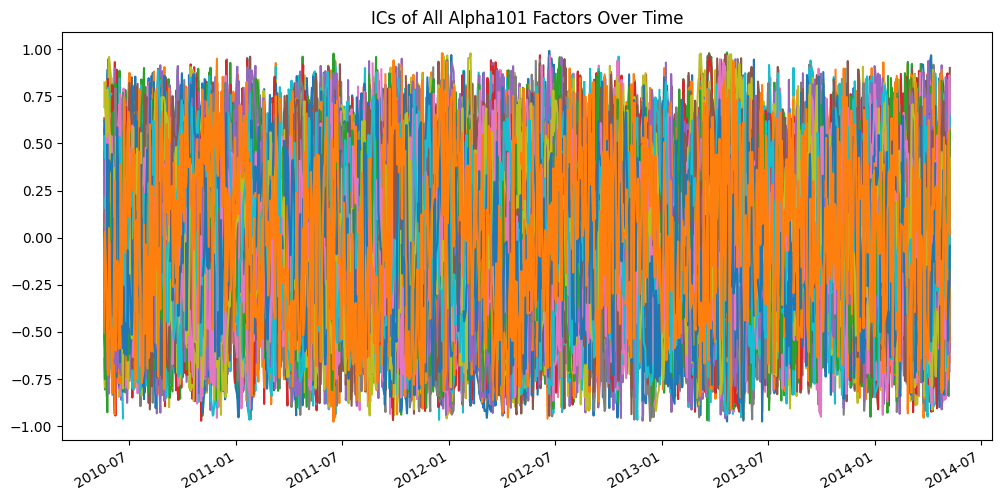

In [22]:
ic_df.iloc[1000:2000].plot(legend=False, figsize=(12,6), title='ICs of All Alpha101 Factors Over Time')

<Axes: title={'center': 'ICs of All Alpha101 Factors Over Time'}>

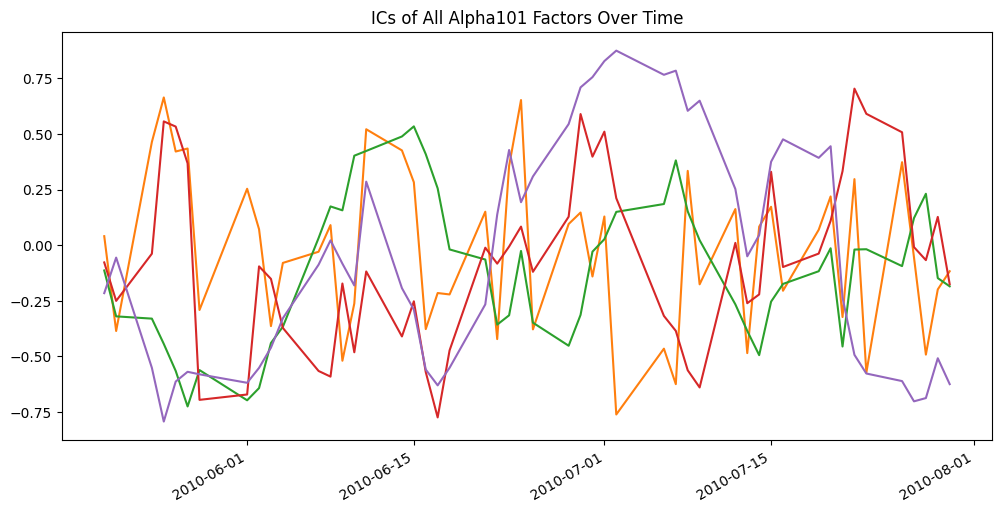

In [23]:
ic_df.iloc[1000:1050][ic_df.columns[random.sample(range(ic_df.shape[1]),5)]]\
    .plot(legend=False, 
          figsize=(12,6), 
          title='ICs of All Alpha101 Factors Over Time')

#### Part 3: Bias correction / neutralisation

Raw factors are not pure predictors, they often capture structural biases like:

- Industry effects (tech stocks move together)

- Size effects (small caps have higher volatility)

- Market-wide trends (momentum correlates with beta)

Neutralization ensures your factor’s correlation with forward returns isn’t just due to those broad effects.

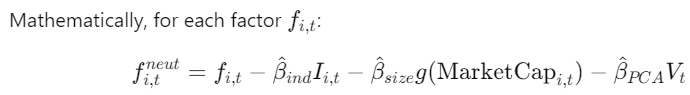

Stage 1. Identify systematic risk factors (via PCA)

Compute correlation matrix of factors.

Extract top K eigenvectors (principal components) representing “market-wide” common movements.

Optional: project factors orthogonally to remove those common components:
​
![image.png](attachment:ed279968-c4f5-4c21-b302-50b718d4710c.png)

Stage 2: Industry neutralisation

Regress each factor cross-sectionally on industry dummy variables:

![image.png](attachment:dde99fde-80d3-420e-8ff6-a12678a4b7fc.png)

Use robust regression (e.g., Huber, ridge) to avoid outlier distortion.

Stage 3: Size neutralisation (market cap bias)

Fit a log-linear model to remove linear and quadratic size effects

Stage 4: Adaptive neutralisation strength

In high-volatility regimes, use stronger neutralization (Du eq. 8):

![image.png](attachment:cc901f04-7497-40fb-9ca0-2b356a48c1cb.png)

Stage 5: Standardisation

After all neutralisation: Cross-sectionally z-score each factor (mean 0, std 1 per day).
This ensures no factor dominates due to scale.

In [24]:
# Neutralisation function
def neutralize_cross_sectional(table, factor_cols, industry_col='industry', cap_col='market_cap', variance_threshold=0.95, ridge_alpha=1.0):
    """
    table: long-format df with columns ['date','ticker', factor_cols..., industry_col, cap_col]
    factor_cols: list of factor column names to neutralize
    variance_threshold: the amount of variance to explain via PCA, e.g., 0.95 means 95% variance
    steps:
      1) for each date, create cross-sectional matrix F (n_stocks x n_factors)
      2) optional: PCA decomposition on F (correlation or covariance) and remove projection onto components that explain the desired variance threshold
      3) industry neutralization: regress each factor on industry dummies (ridge) and subtract predicted
      4) size neutralization: regress residual on log(market_cap) and (log(market_cap))^2
      5) z-score each factor cross-sectionally (per date)
    returns: table with neutralized factor columns appended as e.g. mom12_neut
    """
    out_rows = []
    dates = table['Date'].unique()
    
    for dt in tqdm(dates, desc='Neutralizing per date'):
        slice_df = table[table['Date'] == dt].copy()
        # TODO WHY DO WE NEED TO SKIP IF ITS LESS THAN 10
        # if slice_df.shape[0] < 10:
        #     # too few names - skip neutralization but still zscore
        #     for f in factor_cols:
        #         slice_df[f + '_neut'] = zscore(slice_df[f].fillna(0).values)
        #     out_rows.append(slice_df)
        #     continue
        

        # Build factor matrix F (n_stocks x n_factors)
        F = slice_df[factor_cols].values
        
        # --- PCA removal based on variance threshold
        if variance_threshold is not None and variance_threshold > 0:
            # Standardize the factors (columns mean=0, variance=1)
            scaler = StandardScaler(with_mean=True, with_std=False)
            Fc = scaler.fit_transform(F)
            
            # Perform PCA and get explained variance ratio
            pca = PCA()
            pca.fit(Fc)
            explained_variance_ratio = pca.explained_variance_ratio_

            # Find the number of components that explain at least `variance_threshold` amount of variance
            cumulative_variance = np.cumsum(explained_variance_ratio)
            # n_pcs_remove = np.argmax(cumulative_variance >= variance_threshold) + 1  # Get the number of PCs required
            n_pcs_remove = 1 
            
            # If no components are required to meet the threshold, skip PCA
            # if n_pcs_remove > 0:
            #     pcs = pca.transform(Fc)  # Project data onto the principal components
            #     reconstructed = pca.inverse_transform(pcs[:, :n_pcs_remove])  # Reconstruct the part to remove
            #     F = Fc - reconstructed
            # else:
            #     # If n_pcs_remove is 0, we leave the data unchanged
            #     F = Fc
            # TODO replace above with this to solve the dimension issue
            if n_pcs_remove > 0:
                pcs = pca.transform(Fc)  # Project data onto the principal components
                # Zero out the first n_pcs_remove components
                pcs_filtered = pcs.copy()
                pcs_filtered[:, :n_pcs_remove] = 0
                # Reconstruct using the remaining components
                F = pca.inverse_transform(pcs_filtered)
            else:
                F = Fc

        # Build industry dummies
        industries = pd.get_dummies(slice_df[industry_col].fillna('UNK'))
        
        # Regress each factor on industry dummies (ridge regression)
        X_ind = industries.values
        X_size = np.column_stack([np.log(slice_df[cap_col].values + 1e-9), np.log(slice_df[cap_col].values + 1e-9)**2])
        
        # Industry regression (Ridge to regularize)
        ridge = Ridge(alpha=ridge_alpha, fit_intercept=True)
        F_ind_neut = np.zeros_like(F)
        for j in range(F.shape[1]):
            y = F[:, j]
            # print(X_ind, y)
            ridge.fit(X_ind, y)
            y_hat = ridge.predict(X_ind)
            resid = y - y_hat
            F_ind_neut[:, j] = resid

        # Size neutralization: regress residual on log(cap) and squared
        F_size_neut = np.zeros_like(F_ind_neut)
        ridge2 = Ridge(alpha=ridge_alpha, fit_intercept=True)
        for j in range(F_ind_neut.shape[1]):
            y = F_ind_neut[:, j]
            # print(dt)
            # print(X_size)
            ridge2.fit(X_size, y)
            y_hat = ridge2.predict(X_size)
            resid = y - y_hat
            F_size_neut[:, j] = resid

        # Now z-score each column cross-sectionally
        F_z = (F_size_neut - np.nanmean(F_size_neut, axis=0)) / (np.nanstd(F_size_neut, axis=0) + 1e-9)

        # Attach results
        for idx, ticker in enumerate(slice_df['Ticker'].values):
            for j, f in enumerate(factor_cols):
                slice_df.at[slice_df.index[idx], f + '_neut'] = F_z[idx, j]
        out_rows.append(slice_df)

    out_df = pd.concat(out_rows, axis=0).sort_values(['Date','Ticker']).reset_index(drop=True)
    return out_df

In [25]:
# factor_table.reset_index()

In [26]:
# F = factor_table[alpha_methods].values

# # ---------- QUICK DIAGNOSTICS: find offending columns ----------
# import numpy as np
# col_df = factor_table[alpha_methods]  # pandas view for easy ops
# # threshold for "too large" (tune to your expected scale)
# LARGE_TH = 1e6

# nan_counts = col_df.isna().sum()
# inf_counts = np.isinf(col_df.values).sum(axis=0)
# large_counts = (np.abs(col_df.values) > LARGE_TH).sum(axis=0)
# max_abs = col_df.replace([np.inf, -np.inf], np.nan).abs().max()

# summary = pd.DataFrame({
#     'nan': nan_counts,
#     'inf_count': inf_counts,
#     'large_count': large_counts,
#     'max_abs': max_abs
# }, index=alpha_methods).sort_values(by='large_count', ascending=False)

# print("Per-factor diagnostics (top rows):")
# print(summary.head(20))

# bad_cols = summary[(summary['inf_count']>0) | (summary['large_count']>0)].index.tolist()
# if bad_cols:
#     print("\nOffending columns:", bad_cols)
#     # show rows where any bad value appears
#     bad_mask = np.zeros(len(col_df), dtype=bool)
#     for c in bad_cols:
#         bad_mask |= np.isinf(col_df[c].values) | (np.abs(col_df[c].values) > LARGE_TH)
#     display(factor_table.loc[bad_mask, bad_cols].head(50))
# else:
#     print("No infs or values > LARGE_TH found in this slice.")

In [27]:
# scaler = StandardScaler(with_mean=True, with_std=False)
# Fc = scaler.fit_transform(F)

In [28]:
factor_table[alpha_methods].isnull().sum().sum()

np.int64(0)

In [29]:
neut_df = neutralize_cross_sectional(
    factor_table.reset_index(),
    alpha_methods,
    industry_col='industry',
    cap_col='market_cap')
neut_df

Neutralizing per date: 100%|██████████| 4844/4844 [04:07<00:00, 19.60it/s]


,Date,Ticker,alpha001,alpha002,alpha003,alpha004,alpha005,alpha006,alpha007,alpha008,...,alpha085_neut,alpha086_neut,alpha088_neut,alpha092_neut,alpha094_neut,alpha095_neut,alpha096_neut,alpha098_neut,alpha099_neut,alpha101_neut
0,2006-05-31,XLB,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,1.219421,0.000000,1.489498
1,2006-05-31,XLE,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,-0.159370,0.000000,0.609890
2,2006-05-31,XLF,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,-1.399010,0.000000,-0.501321
3,2006-05-31,XLI,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,-0.629086,0.000000,-0.458049
4,2006-05-31,XLK,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,1.291244,0.000000,0.612433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38747,2025-08-29,XLI,0.537366,0.311329,0.343186,-4.0,-0.000189,0.386651,-1.0,-0.340961,...,-0.139413,0.0,0.150415,-2.086835,-0.497915,0.0,-0.651970,-0.971919,1.378167,0.951394
38748,2025-08-29,XLK,0.519926,0.239366,0.032657,-6.0,-0.001962,0.054550,1.0,-0.594310,...,-0.132197,0.0,-0.458612,0.542119,-0.578369,0.0,-1.237473,-0.151502,-0.406369,0.941267
38749,2025-08-29,XLP,0.822424,0.345818,-0.405612,-2.0,-0.005129,-0.482871,28.0,-0.125335,...,-0.507428,0.0,1.686421,-0.106247,1.765482,0.0,-0.509252,-0.082360,-1.384038,0.239846
38750,2025-08-29,XLU,0.359930,0.574026,-0.134717,-1.0,-0.000039,-0.086269,-1.0,-0.192125,...,-0.047024,0.0,0.199472,1.158055,1.418650,0.0,1.826361,0.793844,-0.753303,-2.336920


In [30]:
idx= 33

df = neut_df[neut_df['Date']==neut_df['Date'][2000]].copy()
corr_before = df[alpha_methods[idx]].corr(df['market_cap'])
corr_after = df[f'{alpha_methods[idx]}_neut'].corr(df['market_cap'])
print(corr_before, corr_after)

-0.15479425801165134 -0.1302006027660956


In [31]:
import random
method = random.choice(alpha_methods)
# Sanity checks to make sure the factors have been properly neutralized
#log_market_cap = np.log(neut_df['market_cap'])

print(f'The mean of {method} is {neut_df[method].mean()}. It should be close to 0')
print(f'The std of {method} is {neut_df[method].std()}. It should be close to 1')

per_date_corrs = neut_df.groupby('Date').apply(
    lambda df: df[method].corr(df['market_cap'])
)
print(per_date_corrs.mean())

#for neut_factor in factor_names[:2]:
#    name = neut_factor + "_neut"
#    print(f'Correlation between {neut_factor} and log market cap is: {neut_df[name].corr(log_market_cap)}. It should be close to 0')
    #print(f'Correlation between {neut_factor} and industry is: {neut_df[name].corr(neut_df['industry'])}. It should be close to 0')

The mean of alpha088 is 0.498220348458758. It should be close to 0
The std of alpha088 is 0.288282010212564. It should be close to 1
0.11220142063664945

/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_15590/1644060755.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_date_corrs = neut_df.groupby('Date').apply(


#### Part 3: Factor quality filtering

Before neutralization, you remove unstable or low-quality factors:

| Metric                           | Meaning                          | Threshold / Use                    |    |       |
| -------------------------------- | -------------------------------- | ---------------------------------- | -- | ----- |
| **Information Coefficient (IC)** | corr(factor, next-period return) | keep if                            | IC | >0.02 |
| **IC stability**                 | std(IC) over time                | remove if too high                 |    |       |
| **Decay**                        | how fast IC drops with horizon   | remove if rapid                    |    |       |
| **Turnover**                     | factor changes too quickly?      | penalize high turnover             |    |       |
| **Correlation matrix**           | inter-factor correlations        | cluster & keep top of each cluster |    |       |


This section determines the quality of the factors by calculating the Information Coefficient (IC) for each factor, which is the cross sectional correlation between a factor's values and next-period returns for each date.

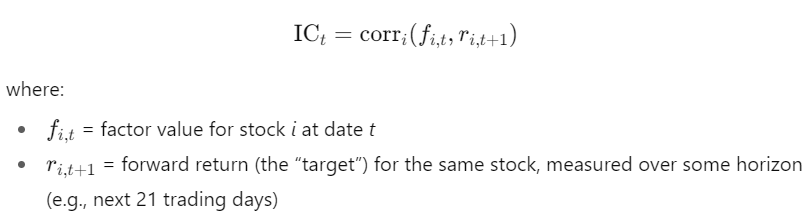

In [32]:
ic_list = [compute_ic(neut_df, col) for col in alpha_methods]
ic_df = pd.concat(ic_list, axis=1)
ic_df.isnull().sum().sort_values().tail(10)

/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


59     784
45     785
6      786
58     861
56     934
20    1048
77    4842
73    4844
26    4844
61    4844
dtype: int64

<Axes: title={'center': 'ICs of All Alpha101 Factors Over Time'}>

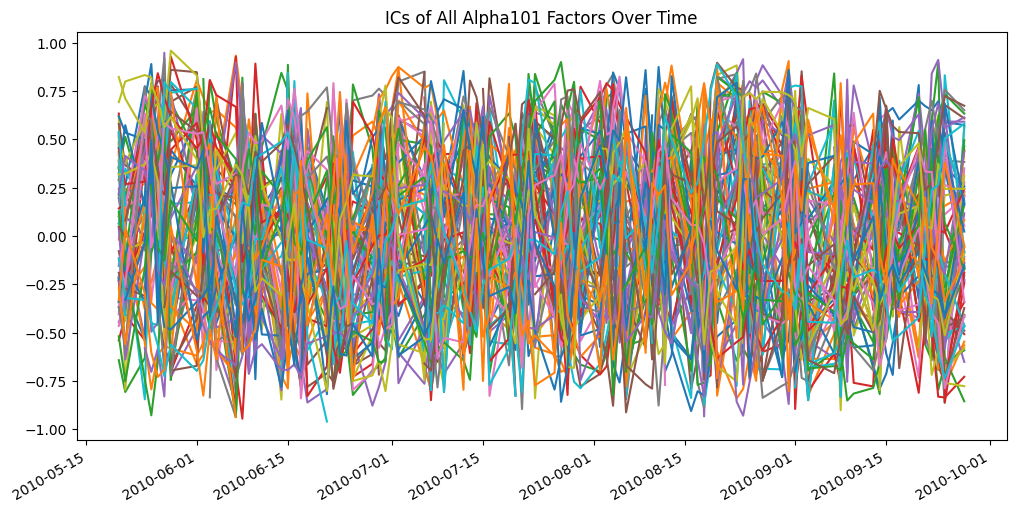

In [35]:
ic_df.iloc[1000:1090].plot(legend=False, figsize=(12,6), title='ICs of All Alpha101 Factors Over Time')

<Axes: title={'center': 'ICs of All Alpha101 Factors Over Time'}>

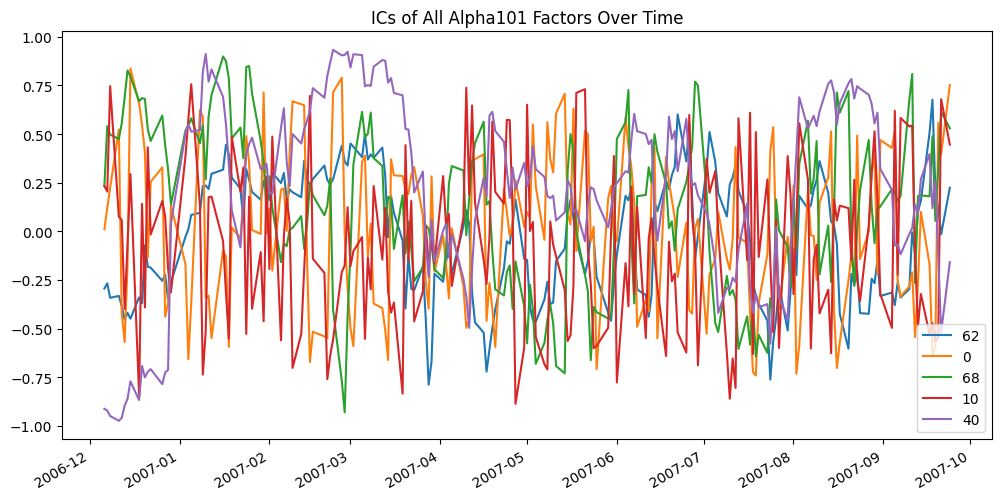

In [58]:
window = 200
start = random.randint(0, len(ic_df) - window)
sampled_rows = ic_df.iloc[start:start + window]
sampled_cols = random.sample(list(ic_df.columns), 5)

sampled_rows[sampled_cols].sort_index().plot(
    legend=True,
    figsize=(12, 6),
    title='ICs of All Alpha101 Factors Over Time'
)

Each IC series is a time series of daily correlations between the neutralized factor values and the forward returns over the 21-day horizon. It is a measure of, on each day, how well the factor's ranking predicted the cross-sectional return ranking over the next period 

Interpretation of mean ICs

| Mean IC    | Typical interpretation                  |
| ---------- | --------------------------------------- |
| > 0.05     | Very strong factor (rare)               |
| 0.02–0.05  | Good, likely tradable                   |
| 0.005–0.02 | Weak but possibly useful in combination |
| ~0         | Noise / no predictive power             |
| < 0        | Inverted signal (could short it)        |


In [65]:
ic_summary = []
for series in ic_df.columns:
    ic_summary.append({
        'Factor': series,
        'Mean IC': ic_df[series].mean(),
        'Std IC': ic_df[series].std(),
        'Information ratio': ic_df[series].mean() / ic_df[series].std(),
        'Hit ratio': (ic_df[series] > 0).mean(),
        'Miss ratio': (ic_df[series] < 0).mean()
    })
ICs_summary = pd.DataFrame(ic_summary)
display(ICs_summary)

,Factor,Mean IC,Std IC,Information ratio,Hit ratio,Miss ratio
0,0,-0.003271,0.414145,-0.007899,0.497729,0.498348
1,1,0.003910,0.404642,0.009663,0.509290,0.486581
2,2,-0.008848,0.406518,-0.021767,0.486168,0.511974
3,3,0.001367,0.447705,0.003053,0.488233,0.475434
4,4,0.006501,0.425345,0.015285,0.503303,0.494633
...,...,...,...,...,...,...
77,77,-0.277782,0.287899,-0.964859,0.000000,0.000413
78,78,0.008317,0.385933,0.021550,0.487614,0.476879
79,79,-0.020537,0.412727,-0.049759,0.483485,0.516515
80,80,-0.000591,0.394504,-0.001499,0.449422,0.445293


In [66]:
# Selection of top factors
# ICs_summary.sort_values(by='Mean IC', ascending=False).head(20)
ICs_summary.sort_values(by='Mean IC', ascending=False).tail(20)

,Factor,Mean IC,Std IC,Information ratio,Hit ratio,Miss ratio
58,58,-0.015741,0.417622,-0.037691,0.395747,0.426507
5,5,-0.015781,0.406914,-0.038783,0.478737,0.519405
17,17,-0.016175,0.427896,-0.037801,0.474195,0.521883
52,52,-0.017095,0.430183,-0.039740,0.420520,0.455615
63,63,-0.019435,0.397537,-0.048890,0.476466,0.523534
79,79,-0.020537,0.412727,-0.049759,0.483485,0.516515
32,32,-0.025161,0.426007,-0.059062,0.476879,0.522709
72,72,-0.025739,0.395016,-0.065159,0.470479,0.521883
46,46,-0.027652,0.418372,-0.066094,0.467795,0.528282
36,36,-0.028008,0.391969,-0.071455,0.455615,0.500000


# Pruning Factors

A multi-factor strategy’s goal isn’t just maximizing each factor’s standalone IC.

It’s about combining diverse, weakly correlated signals so the aggregate IC (or portfolio IR) is more stable.

*Key points:*

- Low correlation / orthogonal ICs → smoother combined performance.
- Factor rotation or pattern recognition (e.g., regime detection via ML or macro states) helps allocate weight dynamically.
- A few moderate-IC but complementary factors can outperform one large-IC factor that decays quickly.
- Think “ensemble learning” — robustness through diversification, not dominance.


> So yes, non-overlapping, compensating IC patterns across factors are often more valuable than one big IC

will remove correlated factors

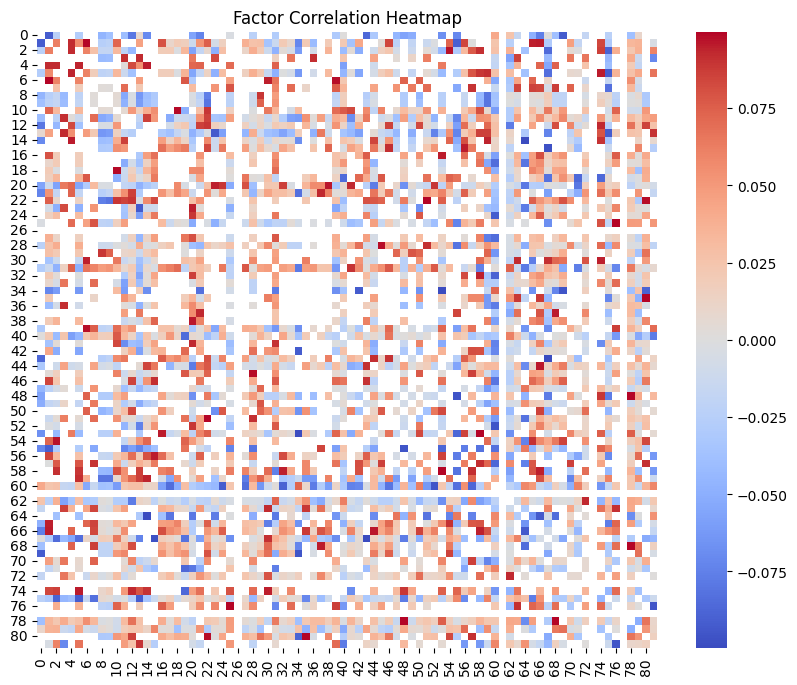

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = ic_df.corr()
# corr = corr[abs(corr) < 0.1]

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Factor Correlation Heatmap")
plt.show()

In [78]:
def prune_redundant_factors(ic_df, corr_threshold=0.8):
    """
    Remove redundant factors that are highly correlated.
    Keeps the one with higher mean IC when |corr| > threshold.

    Parameters
    ----------
    ic_df : pd.DataFrame
        DataFrame of IC values (index = dates, columns = factors)
    corr_threshold : float
        Correlation threshold to treat factors as redundant

    Returns
    -------
    pd.DataFrame
        Filtered IC DataFrame with redundant factors removed
    """
    corr = ic_df.corr()
    mean_ic = ic_df.mean()

    to_drop = set()
    for i in corr.columns:
        for j in corr.columns:
            if i != j and abs(corr.loc[i, j]) > corr_threshold:
                # drop the one with smaller mean IC
                drop = j if mean_ic[i] >= mean_ic[j] else i
                to_drop.add(drop)

    return ic_df.drop(columns=list(to_drop))


In [85]:
ic_df2 = prune_redundant_factors(ic_df, corr_threshold=0.5).dropna(how='all', axis=1)
ic_df2.shape

(4844, 48)

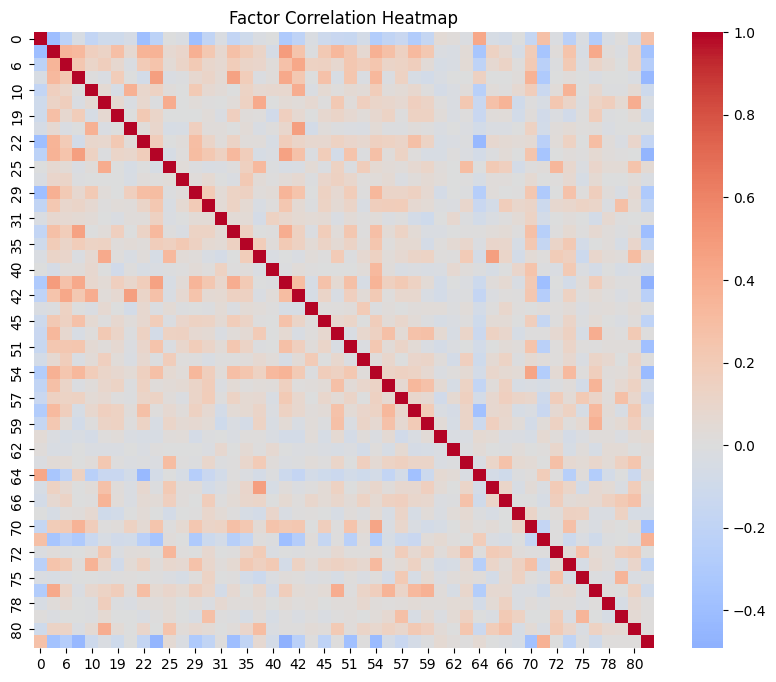

In [86]:
plt.figure(figsize=(10, 8))
sns.heatmap(ic_df2.corr(), annot=False, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Factor Correlation Heatmap")
plt.show()

In [88]:
ic_df2

,0,4,6,9,10,15,19,20,22,23,...,70,71,72,74,75,76,78,79,80,81
2006-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.089167,NaN,0.134878
2006-06-01,NaN,NaN,NaN,0.904225,NaN,NaN,0.218584,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002042,NaN,-0.671407
2006-06-02,NaN,NaN,NaN,-0.696510,NaN,NaN,-0.375909,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.094893,NaN,NaN,NaN,-0.090837,NaN,0.128129
2006-06-05,NaN,NaN,NaN,NaN,NaN,NaN,-0.610868,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.042906,NaN,NaN,NaN,-0.210164,NaN,NaN
2006-06-06,NaN,NaN,NaN,NaN,NaN,-0.410061,NaN,NaN,NaN,-0.381938,...,NaN,NaN,NaN,-0.265202,NaN,NaN,NaN,-0.243421,NaN,0.348509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-25,0.285122,-0.335755,0.378824,0.391406,-0.584935,-0.112331,-0.235859,-0.378824,0.106716,-0.418471,...,0.187620,0.350109,0.487482,-0.049461,-0.209304,0.042641,-0.593919,-0.488246,0.166438,0.236075
2025-08-26,0.454761,0.339439,-0.380637,-0.222982,0.194200,0.139993,-0.580106,-0.380637,-0.406353,-0.566796,...,-0.327803,0.694847,0.779528,0.191823,0.108093,0.072191,-0.297636,-0.306517,-0.350022,0.065677
2025-08-27,0.576118,-0.205246,0.056025,-0.146658,0.581812,0.078070,-0.337554,-0.056025,-0.312206,-0.147759,...,-0.195850,0.594675,0.390152,0.073991,0.616809,0.044778,0.485303,0.114836,-0.161769,0.186526
2025-08-28,0.467118,-0.631106,NaN,-0.041461,0.131445,0.453963,-0.020748,NaN,-0.688851,-0.595723,...,-0.472363,0.503902,0.608012,0.215765,0.827135,-0.090552,0.035338,0.504783,0.165083,0.185712


Factor weighting based on IC:

Equal weighting

- All factors contribute equally, regardless of IC
- The composite alpha represents a simple average of all factors. Negative IC factors still contribute with their original sign.
- Simple and robust, avoids “overfitting” noisy ICs but ignores differences in predictive power

Absolute weighting

- Each factor contributes proportional to the magnitude of its predictive power, ignoring sign. This means that weightages are calculated using absolute value of the ICs, but the sign on the factors themselves is not changed. 
- Factors with stronger predictive strength (positive or negative) get more weight. Negative IC factors are treated as strong predictors, but their direction is not flipped, so their contribution may partially cancel positive IC factors.
- Emphasizes stronger predictors but can reduce signal if positively correlated factors have opposing signs.

Sign-flipped IC weighting

- Each factor contributes proportional to the magnitude of its predictive power, ignoring sign. This means that weightages are calculated using absolute value of the ICs, and the sign on the factors themselves ARE changed to positive as well. 
- The composite alpha now represents a coherent long-short signal, where every factor contributes positively to predicting future returns.
- Avoids cancellation of factors with opposing signs.
- It preserves predictive signal and reduces cancellation, but assumes past negative IC will continue to invert predictively; slightly less conservative.

When to use each:

- Equal weighting: small factor set, noisy IC estimates, want robustness.

- Absolute IC: medium factor set, confident in magnitude of ICs, don’t mind partial cancellation.

- Sign-flipped IC: when factors are few and some have negative ICs, or when you want to maximize the magnitude of your composite signal.

In [ ]:
# build composite alpha function  builds a composite alpha column (the final signal) from the ICs of each factor combined with its weightage
# Weighting is meant to combine factors so that more predictive factors contribute more to the composite alpha
# The coding here uses absolute IC weighting and has parameterisation for equal weighting
def build_composite_alpha(table_neut, factor_cols, ic_summary=None, weighted=False):
    cols_neut = [f + '_neut' for f in factor_cols]
    df = table_neut.copy()
    
    # Define weights
    if weighted and ic_summary is not None:
        weights = np.array([ic_summary.get(f, 0.0) for f in factor_cols])
        weights /= np.sum(np.abs(weights)) + 1e-12
    else:
        weights = np.ones(len(factor_cols)) / len(factor_cols)
    
    # Weighted combination (row-wise dot product)
    df['composite_alpha'] = df[cols_neut].fillna(0).dot(weights)
    
    # Z-score within each date
    df['composite_alpha'] = (df.groupby('Date')['composite_alpha'].transform(lambda x: (x - x.mean()) / (x.std() + 1e-9)))
    return df

In [ ]:
neut_df.head(1)

In [ ]:
# used equal weight for now. 
table_combined = build_composite_alpha(
    neut_df,
    factor_cols=factor_names
)

In [ ]:
table_combined

#### Learning to rank

LTR is a supervised step that replaces or refines the combination step. It involves training a model that ranks stocks by expected future return. Instead of predicting exact returns, it learns an ordering of stocks that maximizes predictive power. LTR can capture non-linear interactions between factors that IC weighting or simple averaging cannot. It’s particularly useful when you have many factors or some factors are highly correlated.

Inputs: 
- Neutralised factor columns (or other features) per stock per date
- Forward returns (target variable)

Outputs:
- A predicted ranking score for each stock per date, essentially a refined composite alpha column like in the traditional pipeline

How it differs from the traditional pipeline

| Step                 | Approach                                                   | Output                                  |
| -------------------- | ---------------------------------------------------------- | --------------------------------------- |
| Equal / IC weighting | Linear combination of factors                              | Composite alpha                         |
| Learning to Rank     | Model (e.g., XGBoost, LightGBM) trained to predict ranking | Refined composite alpha / ranking score
 |


The implementation of RankNet, ListNet, and ListMLE differ in how the input data is constructed and in the loss functions used, the way the model handles input data, and how it processes the output.

**LTR Network**

- Two hidden layers (width tunable), dropout, ReLU activations
- Acts as a score generator: it takes features (neutralised factors) as input and outputs a scalar score per stock
- This stays the same regardless of which LTR method is used

**RankNet, ListNet, ListMLE**

Input processing

| Method                 | Input format                                   | Description                                                                                                                                                   |
| ---------------------- | ---------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **RankNet (pairwise)** | Pairs of stocks `(i, j)` for the same date     | Predicts probability that `i` beats `j` in forward return. Loss compares predicted pairwise order vs actual order.                                             |
| **ListNet (listwise)** | Entire cross-section (list of stocks per date) | Computes a probability distribution over the list (softmax over predicted scores and targets). Loss is cross-entropy between predicted and true distributions. |
| **ListMLE (listwise)** | Entire cross-section (list of stocks per date) | Uses the likelihood of the observed ranking; sorts targets descending, computes log-likelihood of predicted ordering.                                         Loss function
 |


| Method      | Type     | Description                                                                                               |
| ----------- | -------- | --------------------------------------------------------------------------------------------------------- |
| **RankNet** | Pairwise | Compares all pairs of stocks. Encourages the network to give higher scores to stocks with higher returns. |
| **ListNet** | Listwise | Considers the entire list of stocks simultaneously, modeling probability distributions over rankings.     |
| **ListMLE** | Listwise | Maximizes the likelihood of the observed ranking over the list.                                           |


RankNet Implementation

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from hyperopt import hp, fmin, tpe, Trials
import numpy as np
import pandas as pd
from itertools import combinations

# ---------------------------
# Pairwise RankNet dataset
# ---------------------------
class RankNetPairDataset(Dataset):
    def __init__(self, df, factor_cols):
        self.pairs = []
        self.labels = []

        for date in df['Date'].unique():
            slice_df = df[df['Date'] == date]
            X_date = slice_df[factor_cols].values
            y_date = slice_df['fwd_return'].values
            n = len(slice_df)

            for i, j in combinations(range(n), 2):
                if y_date[i] != y_date[j]:
                    self.pairs.append((X_date[i], X_date[j]))
                    self.labels.append(1 if y_date[i] > y_date[j] else 0)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        X_i, X_j = self.pairs[idx]
        label = self.labels[idx]
        return (
            torch.tensor(X_i, dtype=torch.float32),
            torch.tensor(X_j, dtype=torch.float32),
            torch.tensor(label, dtype=torch.float32)
        )

# ---------------------------
# Generic feedforward network for LTR
# ---------------------------
class LTRNet(nn.Module):
    def __init__(self, input_dim, hidden_dim1=64, hidden_dim2=32, dropout_rate=0.2):
        super(LTRNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim2, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(-1)

# ---------------------------
# Pairwise RankNet loss
# ---------------------------
def ranknet_pairwise_loss(model, X_i, X_j, y_ij, sigma=1.0):
    score_i = model(X_i)
    score_j = model(X_j)
    P_ij = torch.sigmoid(sigma * (score_i - score_j))
    loss = - (y_ij * torch.log(P_ij + 1e-9) + (1 - y_ij) * torch.log(1 - P_ij + 1e-9))
    return loss.mean()

# ---------------------------
# Training loop for pairwise RankNet
# ---------------------------
def train_ranknet(model, train_loader, val_loader, lr=1e-3,
                  max_epochs=100, patience=25, device='cpu'):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val_loss = np.inf
    patience_counter = 0
    best_state = None

    model.to(device)

    for epoch in range(max_epochs):
        model.train()
        train_loss = 0.0
        for X_i, X_j, y_ij in train_loader:
            X_i, X_j, y_ij = X_i.to(device), X_j.to(device), y_ij.to(device)
            optimizer.zero_grad()
            loss = ranknet_pairwise_loss(model, X_i, X_j, y_ij)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_i.size(0)
        train_loss /= len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_i, X_j, y_ij in val_loader:
                X_i, X_j, y_ij = X_i.to(device), X_j.to(device), y_ij.to(device)
                loss = ranknet_pairwise_loss(model, X_i, X_j, y_ij)
                val_loss += loss.item() * X_i.size(0)
        val_loss /= len(val_loader.dataset)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss

# ---------------------------
# Prepare dataset
# ---------------------------
factor_cols = [c for c in neut_df.columns if c.endswith('_neut')]
dataset = RankNetPairDataset(neut_df, factor_cols)

# Split into train/val (simple 90/10 split)
n_train = int(0.9 * len(dataset))
n_val = len(dataset) - n_train
train_ds, val_ds = torch.utils.data.random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128)

# ---------------------------
# HyperOpt search space
# ---------------------------
space = {
    'hidden_dim1': hp.choice('hidden_dim1', [32, 64, 128]),
    'hidden_dim2': hp.choice('hidden_dim2', [16, 32, 64]),
    'dropout_rate': hp.uniform('dropout_rate', 0.0, 0.5),
    'lr': hp.loguniform('lr', np.log(1e-4), np.log(1e-2))
}

def objective(params):
    model = LTRNet(input_dim=len(factor_cols),
                   hidden_dim1=params['hidden_dim1'],
                   hidden_dim2=params['hidden_dim2'],
                   dropout_rate=params['dropout_rate'])
    model, val_loss = train_ranknet(model, train_loader, val_loader,
                                    lr=params['lr'],
                                    max_epochs=100,
                                    patience=25)
    return val_loss

trials = Trials()
best = fmin(objective, space, algo=tpe.suggest, max_evals=50, trials=trials)
print("Best hyperparameters:", best)

torch.save(model.state_dict(), "ranknet_best_model.pth")
print("✅ Model retrained and saved as ranknet_best_model.pth")

Listnet / ListMLE implementation

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from hyperopt import hp, fmin, tpe, Trials
import numpy as np
import pandas as pd

# ---------------------------
# Listwise dataset per date
# ---------------------------
class ListwiseDataset(Dataset):
    def __init__(self, df, factor_cols):
        self.data = []
        self.targets = []
        for date in df['date'].unique():
            slice_df = df[df['date']==date]
            X_date = slice_df[factor_cols].values
            y_date = slice_df['fwd_return'].values
            self.data.append(torch.tensor(X_date, dtype=torch.float32))
            self.targets.append(torch.tensor(y_date, dtype=torch.float32))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]

# ---------------------------
# Feedforward network
# ---------------------------
class LTRNet(nn.Module):
    def __init__(self, input_dim, hidden_dim1=64, hidden_dim2=32, dropout_rate=0.2):
        super(LTRNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim2, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(-1)

# ---------------------------
# Loss functions
# ---------------------------
def ranknet_loss(scores, targets, sigma=1.0):
    diff = targets.unsqueeze(1) - targets.unsqueeze(0)
    mask = (diff > 0).float()
    score_diff = scores.unsqueeze(1) - scores.unsqueeze(0)
    P = torch.sigmoid(sigma * score_diff)
    loss = -torch.log(P + 1e-9) * mask
    return loss.sum() / (mask.sum() + 1e-9)

def listnet_loss(scores, targets):
    p_true = torch.softmax(targets, dim=0)
    p_pred = torch.softmax(scores, dim=0)
    return -torch.sum(p_true * torch.log(p_pred + 1e-9))

def listmle_loss(scores, targets):
    sorted_idx = torch.argsort(targets, descending=True)
    scores_sorted = scores[sorted_idx]
    loss = 0.0
    for i in range(len(scores_sorted)):
        loss += -(scores_sorted[i] - torch.logsumexp(scores_sorted[i:], dim=0))
    return loss / len(scores_sorted)

# ---------------------------
# Training function
# ---------------------------
def train_listwise(model, train_loader, val_loader, loss_fn,
                   lr=1e-3, max_epochs=100, patience=25, device='cpu'):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val_loss = np.inf
    patience_counter = 0
    best_state = None

    model.to(device)

    for epoch in range(max_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            scores = model(X_batch)
            loss = loss_fn(scores, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                scores = model(X_val)
                val_loss += loss_fn(scores, y_val).item()
        val_loss /= len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_val_loss

# ---------------------------
# Prepare dataset
# ---------------------------
factor_cols = [c for c in neut_df.columns if c.endswith('_neut')]
dataset = ListwiseDataset(neut_df, factor_cols)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)  # one date per batch
val_loader = DataLoader(val_ds, batch_size=1)

# ---------------------------
# HyperOpt search space
# ---------------------------
space = {
    'hidden_dim1': hp.choice('hidden_dim1', [32, 64, 128]),
    'hidden_dim2': hp.choice('hidden_dim2', [16, 32, 64]),
    'dropout_rate': hp.uniform('dropout_rate', 0.0, 0.5),
    'lr': hp.loguniform('lr', np.log(1e-4), np.log(1e-2))
}

def objective(params, loss_type='listnet'):
    model = LTRNet(input_dim=len(factor_cols),
                   hidden_dim1=params['hidden_dim1'],
                   hidden_dim2=params['hidden_dim2'],
                   dropout_rate=params['dropout_rate'])
    
    if loss_type == 'ranknet':
        loss_fn = ranknet_loss
    elif loss_type == 'listnet':
        loss_fn = listnet_loss
    elif loss_type == 'listmle':
        loss_fn = listmle_loss
    else:
        raise ValueError("Unknown loss type")

    model, val_loss = train_listwise(model, train_loader, val_loader,
                                     loss_fn=loss_fn,
                                     lr=params['lr'],
                                     max_epochs=100,
                                     patience=25)
    return val_loss

# ---------------------------
# Run HyperOpt
# ---------------------------
ltr_method = 'listnet'  # 'listnet', 'listmle'

trials = Trials()
best = fmin(lambda p: objective(p, loss_type=ltr_method),
            space, algo=tpe.suggest, max_evals=50, trials=trials)
print(f"Best hyperparameters for {ltr_method}:", best)

save_name = ltr_method + "_best_model.pth"
torch.save(model.state_dict(), save_name)
print(f'✅ Model retrained and saved as {save_name}')

LambdaMART implementation

In [ ]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK

# =========================================================
# 1️⃣ Prepare data
# =========================================================
factor_cols = [c for c in neut_df.columns if c.endswith('_neut')]
X = neut_df[factor_cols].values
y = neut_df['fwd_return'].values
dates = neut_df['date'].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split by date to prevent leakage
unique_dates = np.array(sorted(neut_df['date'].unique()))
train_dates, val_dates = train_test_split(unique_dates, test_size=0.1, shuffle=False)

train_idx = neut_df['date'].isin(train_dates)
val_idx   = neut_df['date'].isin(val_dates)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val     = X[val_idx], y[val_idx]

# Group sizes (number of stocks per date)
group_train = neut_df[train_idx].groupby('date').size().to_numpy()
group_val   = neut_df[val_idx].groupby('date').size().to_numpy()

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)
dtrain.set_group(group_train)
dval.set_group(group_val)

# =========================================================
# 2️⃣ Define HyperOpt search space
# =========================================================
space = {
    'eta': hp.loguniform('eta', np.log(0.01), np.log(0.3)),
    'max_depth': hp.choice('max_depth', [4, 6, 8, 10]),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'lambda': hp.loguniform('lambda', np.log(1e-3), np.log(10)),
    'min_child_weight': hp.uniform('min_child_weight', 5, 50),
}

# =========================================================
# 3️⃣ Objective function for HyperOpt
# =========================================================
def objective(params):
    params = {
        'objective': 'rank:ndcg',     # LambdaMART
        'eval_metric': 'ndcg',
        'tree_method': 'hist',
        'random_state': 42,
        **params
    }

    evals = [(dtrain, 'train'), (dval, 'val')]
    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=1000,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    best_loss = float(model.best_score)  # NDCG; higher is better
    return {'loss': -best_loss, 'status': STATUS_OK, 'model': model}

# =========================================================
# 4️⃣ Run HyperOpt search
# =========================================================
trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(42)
)

# Recover best model
best_trial = min(trials.results, key=lambda r: r['loss'])
best_model = best_trial['model']

print("\n✅ Best parameters:")
print(best)
print(f"Best validation NDCG: {-best_trial['loss']:.4f}")

best_model.save_model("best_model_LambdaMART.json")
print("✅ Model retrained and saved as best_model_LambdaMART.json")

##### Using the trained models

In [ ]:
# Loading the Ranknet model
model = LTRNet(input_dim=X.shape[1],
               hidden_dim1=best_params['hidden_dim1'],
               hidden_dim2=best_params['hidden_dim2'],
               dropout_rate=best_params['dropout_rate'])
model.load_state_dict(torch.load("best_ranknet.pth"))
model.eval()

# Predict scores
X_all = torch.tensor(neut_df[factor_cols].values, dtype=torch.float32)
with torch.no_grad():
    scores = model(X_all).numpy()

# Add signal column
neut_df['signal_ranknet'] = scores

# Normalise, like Du has done
neut_df['signal_ranknet'] = (
    neut_df.groupby('date')['signal_ranknet']
           .transform(lambda x: (x - x.mean()) / (x.std() + 1e-9))
)

#### Unused code

In [ ]:
def neutralize_cross_sectional_buckets(table, factor_cols, industry_col='industry', cap_col='market_cap',
                                       pca_remove_var=0.5, n_size_buckets=10, ridge_alpha=1.0):
    """
    Neutralize factors cross-sectionally:
    - PCA removal (optional)
    - Industry + size bucket regression (removes linear and non-linear size effects)
    - Final z-score per date
    """
    out_rows = []
    dates = table['Date'].unique()
    
    for dt in tqdm(dates, desc='Neutralizing per date'):
        slice_df = table[table['Date'] == dt].copy()
        if slice_df.shape[0] < 10:
            # too few names - just z-score
            for f in factor_cols:
                slice_df[f + '_neut'] = (slice_df[f] - slice_df[f].mean()) / (slice_df[f].std() + 1e-9)
            out_rows.append(slice_df)
            continue
        
        # Factor matrix
        F = slice_df[factor_cols].values
        Fc = StandardScaler().fit_transform(F)
        
        # --- PCA removal
        pca = PCA()
        pca.fit(Fc)
        cumvar = np.cumsum(pca.explained_variance_ratio_)
        n_remove = np.searchsorted(cumvar, pca_remove_var) + 1
        if n_remove > 0:
            pcs = pca.transform(Fc)
            reconstructed = pca.inverse_transform(pcs[:, :n_remove])
            F = Fc - reconstructed
        else:
            F = Fc
        
        # --- Industry dummies
        industries = pd.get_dummies(slice_df[industry_col].fillna('UNK'))
        X_ind = industries.values
        
        # --- Size buckets
        size_bucket = pd.qcut(slice_df[cap_col], n_size_buckets, labels=False)
        size_dummies = pd.get_dummies(size_bucket, prefix='size')
        X_size = size_dummies.values
        
        # Combine industry + size buckets
        X = np.hstack([X_ind, X_size])
        
        # Regress each factor on X and take residuals
        F_neut = np.zeros_like(F)
        ridge = Ridge(alpha=ridge_alpha, fit_intercept=True)
        for j in range(F.shape[1]):
            y = F[:, j]
            ridge.fit(X, y)
            resid = y - ridge.predict(X)
            F_neut[:, j] = resid
        
        # Z-score
        F_z = (F_neut - np.nanmean(F_neut, axis=0)) / (np.nanstd(F_neut, axis=0) + 1e-9)
        
        # Attach results
        for idx, ticker in enumerate(slice_df['ticker'].values):
            for j, f in enumerate(factor_cols):
                slice_df.at[slice_df.index[idx], f + '_neut'] = F_z[idx, j]
        
        out_rows.append(slice_df)
    
    out_df = pd.concat(out_rows, axis=0).sort_values(['Date','ticker']).reset_index(drop=True)
    return out_df